In [1]:
import numpy as np
import pandas as pd
import seaborn as sns

Pivot_table
- the pivot_table takes simple column wise data as input and groups the entries into a two - dimensional table that provides a multidimensional summarization of data.
- pivot_table works on categorical data
- means ()

In [2]:
df = sns.load_dataset('tips')

In [3]:
df

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


In [4]:
# to find avg
df.groupby('sex')['total_bill'].mean().reset_index()
df.groupby('sex')[['total_bill']].mean()

C:\Users\soura\AppData\Local\Temp\ipykernel_18380\3113373909.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('sex')['total_bill'].mean().reset_index()
C:\Users\soura\AppData\Local\Temp\ipykernel_18380\3113373909.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('sex')[['total_bill']].mean()


,total_bill
sex,
Male,20.744076
Female,18.056897


In [5]:
df.groupby(['sex','smoker'])[['total_bill']].mean()
# this is multiindex dataframe
df.groupby(['sex','smoker'])[['total_bill']].mean().unstack()

C:\Users\soura\AppData\Local\Temp\ipykernel_18380\509214530.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['sex','smoker'])[['total_bill']].mean()
C:\Users\soura\AppData\Local\Temp\ipykernel_18380\509214530.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['sex','smoker'])[['total_bill']].mean().unstack()


total_bill           
smoker        Yes         No
sex                         
Male    22.284500  19.791237
Female  17.977879  18.105185

In [6]:
df.pivot_table(index='sex',columns='smoker',values='total_bill')
# here agg function is mean

C:\Users\soura\AppData\Local\Temp\ipykernel_18380\2668939670.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df.pivot_table(index='sex',columns='smoker',values='total_bill')


smoker,Yes,No
sex,,
Male,22.284500,19.791237
Female,17.977879,18.105185


In [7]:
df.pivot_table(index='sex',columns='smoker',values='total_bill',aggfunc='sum')

C:\Users\soura\AppData\Local\Temp\ipykernel_18380\3627826641.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df.pivot_table(index='sex',columns='smoker',values='total_bill',aggfunc='sum')


smoker,Yes,No
sex,,
Male,1337.07,1919.75
Female,593.27,977.68


In [8]:
# all columns together
df[['sex','size','tip','total_bill','smoker']].pivot_table(index='sex',columns='smoker')
df[['sex','size','tip','total_bill','smoker']].pivot_table(index='sex',columns='smoker')['tip']

C:\Users\soura\AppData\Local\Temp\ipykernel_18380\1772543758.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df[['sex','size','tip','total_bill','smoker']].pivot_table(index='sex',columns='smoker')
C:\Users\soura\AppData\Local\Temp\ipykernel_18380\1772543758.py:3: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df[['sex','size','tip','total_bill','smoker']].pivot_table(index='sex',columns='smoker')['tip']


smoker,Yes,No
sex,,
Male,3.051167,3.113402
Female,2.931515,2.773519


In [9]:
df.pivot_table(index=['sex','smoker'],columns=['day','time'],values='total_bill')
df.pivot_table(index=['sex','smoker'],columns=['day','time'],aggfunc={'size':'mean','tip':'max','total_bill':'sum'})
# 5D analysis

C:\Users\soura\AppData\Local\Temp\ipykernel_18380\2649217061.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df.pivot_table(index=['sex','smoker'],columns=['day','time'],values='total_bill')
C:\Users\soura\AppData\Local\Temp\ipykernel_18380\2649217061.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df.pivot_table(index=['sex','smoker'],columns=['day','time'],aggfunc={'size':'mean','tip':'max','total_bill':'sum'})


size                                               tip  \
day                Thur              Fri              Sat       Sun  Thur   
time              Lunch Dinner     Lunch Dinner    Dinner    Dinner Lunch   
sex    smoker                                                               
Male   Yes     2.300000    NaN  1.666667    2.4  2.629630  2.600000  5.00   
       No      2.500000    NaN       NaN    2.0  2.656250  2.883721  6.70   
Female Yes     2.428571    NaN  2.000000    2.0  2.200000  2.500000  5.00   
       No      2.500000    2.0  3.000000    2.0  2.307692  3.071429  5.17   

                                                total_bill                \
day                    Fri           Sat    Sun       Thur           Fri   
time          Dinner Lunch Dinner Dinner Dinner      Lunch Dinner  Lunch   
sex    smoker                                                              
Male   Yes       NaN  2.20   4.73  10.00    6.5     191.71   0.00  34.16   
       No        NaN   NaN   3.50   9.00    6.0     369.73   0.00   0.00   
Female Yes       NaN  3.48   4.30   6.50    4.0     134.53   0.00  39.78   
       No        3.0  3.00   3.25   4.67    5.2     381.58  18.78  15.98   

                                                   
day                     Sat           Sun          
time           Dinner Lunch  Dinner Lunch  Dinner  
sex    smoker                                      
Male   Yes     129.46   0.0  589.62   0.0  392.12  
       No       34.95   0.0  637.73   0.0  877.34  
Female Yes      48.80   0.0  304.00   0.0   66.16  
       No       22.75   0.0  247.05   0.0  291.54

In [10]:
df.pivot_table(index='sex',columns='smoker',values='total_bill',aggfunc='sum',margins=True)
# margin gives sum of all rows

C:\Users\soura\AppData\Local\Temp\ipykernel_18380\3440595942.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df.pivot_table(index='sex',columns='smoker',values='total_bill',aggfunc='sum',margins=True)


smoker,Yes,No,All
sex,,,
Male,1337.07,1919.75,3256.82
Female,593.27,977.68,1570.95
All,1930.34,2897.43,4827.77


In [11]:
# we can plot graph using pivot_table
df = pd.read_csv('expense_data.csv')
df

,Date,Account,Category,Subcategory,Note,INR,Income/Expense,Note.1,Amount,Currency,Account.1
0,3/2/2022 10:11,CUB - online payment,Food,NaN,Brownie,50.0,Expense,NaN,50.0,INR,50.0
1,3/2/2022 10:11,CUB - online payment,Other,NaN,To lended people,300.0,Expense,NaN,300.0,INR,300.0
2,3/1/2022 19:50,CUB - online payment,Food,NaN,Dinner,78.0,Expense,NaN,78.0,INR,78.0
3,3/1/2022 18:56,CUB - online payment,Transportation,NaN,Metro,30.0,Expense,NaN,30.0,INR,30.0
4,3/1/2022 18:22,CUB - online payment,Food,NaN,Snacks,67.0,Expense,NaN,67.0,INR,67.0
...,...,...,...,...,...,...,...,...,...,...,...
272,11/22/2021 14:16,CUB - online payment,Food,NaN,Dinner,90.0,Expense,NaN,90.0,INR,90.0
273,11/22/2021 14:16,CUB - online payment,Food,NaN,Lunch with company,97.0,Expense,NaN,97.0,INR,97.0
274,11/21/2021 17:07,CUB - online payment,Transportation,NaN,Rapido,130.0,Expense,NaN,130.0,INR,130.0
275,11/21/2021 15:50,CUB - online payment,Food,NaN,Lunch,875.0,Expense,NaN,875.0,INR,875.0


In [12]:
df['Category'].value_counts()

Category
Food                156
Other                60
Transportation       31
Apparel               7
Household             6
Allowance             6
Social Life           5
Education             1
Salary                1
Self-development      1
Beauty                1
Gift                  1
Petty cash            1
Name: count, dtype: int64

In [13]:
df.info()
# initially the date column is an object(String)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 277 entries, 0 to 276
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            277 non-null    object 
 1   Account         277 non-null    object 
 2   Category        277 non-null    object 
 3   Subcategory     0 non-null      float64
 4   Note            273 non-null    object 
 5   INR             277 non-null    float64
 6   Income/Expense  277 non-null    object 
 7   Note.1          0 non-null      float64
 8   Amount          277 non-null    float64
 9   Currency        277 non-null    object 
 10  Account.1       277 non-null    float64
dtypes: float64(5), object(6)
memory usage: 23.9+ KB


In [14]:
df['Date'] = pd.to_datetime(df['Date'])

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 277 entries, 0 to 276
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Date            277 non-null    datetime64[ns]
 1   Account         277 non-null    object        
 2   Category        277 non-null    object        
 3   Subcategory     0 non-null      float64       
 4   Note            273 non-null    object        
 5   INR             277 non-null    float64       
 6   Income/Expense  277 non-null    object        
 7   Note.1          0 non-null      float64       
 8   Amount          277 non-null    float64       
 9   Currency        277 non-null    object        
 10  Account.1       277 non-null    float64       
dtypes: datetime64[ns](1), float64(5), object(5)
memory usage: 23.9+ KB


In [16]:
df['Month'] = df['Date'].dt.month_name()

In [17]:
df.head()

,Date,Account,Category,Subcategory,Note,INR,Income/Expense,Note.1,Amount,Currency,Account.1,Month
0,2022-03-02 10:11:00,CUB - online payment,Food,NaN,Brownie,50.0,Expense,NaN,50.0,INR,50.0,March
1,2022-03-02 10:11:00,CUB - online payment,Other,NaN,To lended people,300.0,Expense,NaN,300.0,INR,300.0,March
2,2022-03-01 19:50:00,CUB - online payment,Food,NaN,Dinner,78.0,Expense,NaN,78.0,INR,78.0,March
3,2022-03-01 18:56:00,CUB - online payment,Transportation,NaN,Metro,30.0,Expense,NaN,30.0,INR,30.0,March
4,2022-03-01 18:22:00,CUB - online payment,Food,NaN,Snacks,67.0,Expense,NaN,67.0,INR,67.0,March


<Axes: xlabel='Month'>

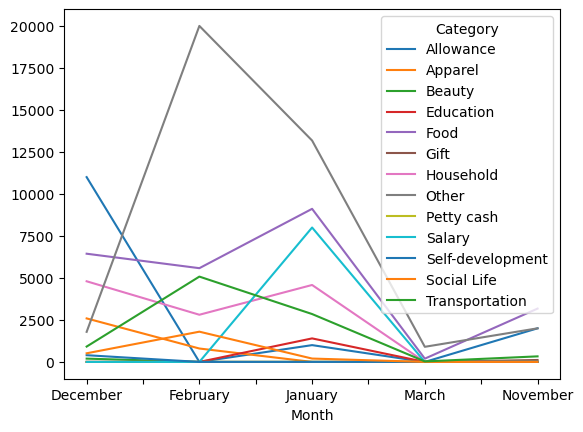

In [18]:
# we can plot a graph using pivot_table
df.pivot_table(index='Month',columns='Category',values='INR',aggfunc='sum')
df.pivot_table(index='Month',columns='Category',values='INR',aggfunc='sum',fill_value=0).plot()

<Axes: xlabel='Month'>

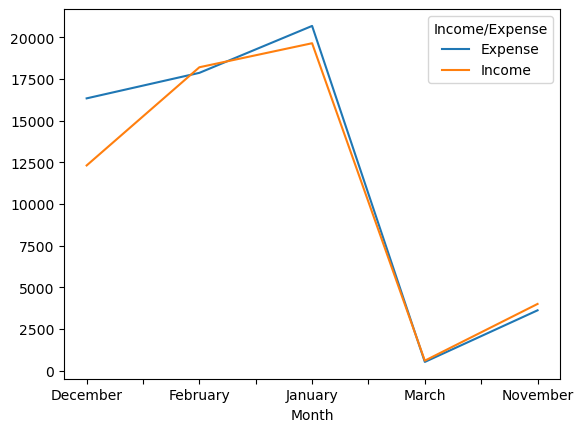

In [19]:
df.pivot_table(index='Month',columns='Income/Expense',values='INR',aggfunc='sum',fill_value=0).plot()

Vectorize String Operations

In [20]:
# what is vectorized operations
a = np.array([1,2,3,4,5])

In [21]:
a*4

array([ 4,  8, 12, 16, 20])

In [ ]:
# 
s = ['cat','mat',None,'rat']
[i.startswith('c') for i in s]

# this code will not execute since there is None type data
# abd it also slow

In [27]:
# fast and optimized approach with pandas
s = pd.Series(['cat','mat',None,'rat'])
# string accessor
s.str.startswith('c')

0     True
1    False
2     None
3    False
dtype: object

String Operations with Pandas

In [31]:
df = pd.read_csv('titanic.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [32]:
df['Name']

0                                Braund, Mr. Owen Harris
1      Cumings, Mrs. John Bradley (Florence Briggs Th...
2                                 Heikkinen, Miss. Laina
3           Futrelle, Mrs. Jacques Heath (Lily May Peel)
4                               Allen, Mr. William Henry
                             ...                        
886                                Montvila, Rev. Juozas
887                         Graham, Miss. Margaret Edith
888             Johnston, Miss. Catherine Helen "Carrie"
889                                Behr, Mr. Karl Howell
890                                  Dooley, Mr. Patrick
Name: Name, Length: 891, dtype: object

In [45]:
# common functions

# lower/upper/capitalized/title

df['Name'].str.title()
df['Name'].str.lower()
df['Name'].str.upper()
df['Name'].str.capitalize()

# len
df['Name'][df['Name'].str.len() == 82].values[0]  # max length of name

# strip
# to remove extra space
"     sourabh   ".strip()
df["Name"].str.strip()

0                                Braund, Mr. Owen Harris
1      Cumings, Mrs. John Bradley (Florence Briggs Th...
2                                 Heikkinen, Miss. Laina
3           Futrelle, Mrs. Jacques Heath (Lily May Peel)
4                               Allen, Mr. William Henry
                             ...                        
886                                Montvila, Rev. Juozas
887                         Graham, Miss. Margaret Edith
888             Johnston, Miss. Catherine Helen "Carrie"
889                                Behr, Mr. Karl Howell
890                                  Dooley, Mr. Patrick
Name: Name, Length: 891, dtype: object

In [59]:
# split -> get

# fetching surname
df['lastName'] = df['Name'].str.split(',').str.get(0)

# fetching name
df[['title','firstname']] = df['Name'].str.split(',').str.get(1).str.strip().str.split(' ',n=1,expand=True)
# here n parameter is used to show how many spliting operation do you want to perform
# expand make dataframe for your n (spliting number)

In [64]:
df.head()
df.groupby('title')['title'].count()

title
Capt.          1
Col.           2
Don.           1
Dr.            7
Jonkheer.      1
Lady.          1
Major.         2
Master.       40
Miss.        182
Mlle.          2
Mme.           1
Mr.          517
Mrs.         125
Ms.            1
Rev.           6
Sir.           1
the            1
Name: title, dtype: int64

In [67]:
# replace
df['title'] = df['title'].str.replace('Ms.','Miss.')
df['title']=df['title'].str.replace('Mlle.','Miss.')

In [71]:
df.groupby('title')['title'].count().sort_values(ascending=False)

title
Mr.          517
Miss.        185
Mrs.         125
Master.       40
Dr.            7
Rev.           6
Col.           2
Major.         2
Capt.          1
Don.           1
Jonkheer.      1
Lady.          1
Mme.           1
Sir.           1
the            1
Name: title, dtype: int64

In [74]:
# filtering
df['firstname'][df['firstname'].str.startswith('A')].count()

np.int64(95)

In [75]:
# filtering
df['firstname'][df['firstname'].str.endswith('A')].count()

np.int64(2)

In [79]:
# isdigit/isAlpha
df['firstname'][df['firstname'].str.isdigit()].count()
df['firstname'][df['firstname'].str.isalpha()].count()


np.int64(310)

In [83]:
# advance level fitering
# applying regex
# contains
# search john -> both case

df['firstname'][df['firstname'].str.contains('john',case=False)].count()

np.int64(44)

In [ ]:
# find lastname with start and end char vowel
df['lastName'][df['lastName'].str.contains('^[aeiouAEIOU].+[aeiouAEIOU]$')]
# ^ sign represents first char
# $ sign represents last char
# . sign represents one or more
# + both conditions
# this is called regular expresion

df['lastName'][df['lastName'].str.contains('^[^aeiouAEIOU].+[^aeiouAEIOU]$')]
# ata he aatle ^ sign sangte ki he sodun kahi pan asudet

0         Braund
1        Cumings
2      Heikkinen
5          Moran
6       McCarthy
         ...    
884     Sutehall
887       Graham
888     Johnston
889         Behr
890       Dooley
Name: lastName, Length: 671, dtype: object

In [92]:
# slicing
df['Name'].str[::2]
df['Name'].str[::-1]

0                                sirraH newO .rM ,dnuarB
1      )reyahT sggirB ecnerolF( yeldarB nhoJ .srM ,sg...
2                                 aniaL .ssiM ,nenikkieH
3           )leeP yaM yliL( htaeH seuqcaJ .srM ,ellertuF
4                               yrneH mailliW .rM ,nellA
                             ...                        
886                                sazouJ .veR ,alivtnoM
887                         htidE teragraM .ssiM ,maharG
888             "eirraC" neleH enirehtaC .ssiM ,notsnhoJ
889                                llewoH lraK .rM ,rheB
890                                  kcirtaP .rM ,yelooD
Name: Name, Length: 891, dtype: object

Date And Time

TimeStamp Object
Date Time index 
1) Timestamp object
- timestamp refers pertiular moments in time(e.g.,Oct 24th,  2022 at 7:00pm)

In [ ]:
# creating a timestamp
# the parameter must be an string
type(pd.Timestamp('2023/1/5'))

# method 2
pd.Timestamp('2023-2-5')

# method 3
pd.Timestamp('2023, 2, 5')
# after comma space is required

Timestamp('2023-02-05 00:00:00')

In [104]:
# only year
pd.Timestamp('2025')

# using text
pd.Timestamp('5th March 2026')

Timestamp('2026-03-05 00:00:00')

In [ ]:
# providing timestamp
pd.Timestamp('5th March 2026 9:21pm')
pd.Timestamp('5th March 2026 9:21pm')


Timestamp('2026-03-05 21:21:00')

In [120]:
import datetime as dt

dt.datetime(2026, 5, 3)

datetime.datetime(2026, 5, 3, 0, 0)

In [122]:
x = pd.Timestamp(dt.datetime(2026, 5, 3))

In [127]:
x.year
x.month
x.day

3

##### python datetime vs pandas timestamp
- syntax wise datetime is very convenient
- but the performance takes a hit while working huge dara. list vs numpy array
- the weakness of pythons datetime formad inspired the NumPy team to add a set of native time series data type to numpy
- the datetime 64 dtype encodes dates as 64-bit integers, and thus allows arrays of dates to be represented very compactly.

In [133]:
date = np.array('2026-05-25',dtype=np.datetime64)

- pandas timestamp object combines the ease-of-use of python datetime with the efficient storage and vectorizes interface of numpy.datetime64
- from a group of these timestamp objects, pandas can construct a datetneIndex that can be used to index data in a series or dataframe

In [135]:
# numpy supports datetime64 as dtype.
# by using this we can easily make all numpy vector operations on that array
date + np.arange(10)

array(['2026-05-25', '2026-05-26', '2026-05-27', '2026-05-28',
       '2026-05-29', '2026-05-30', '2026-05-31', '2026-06-01',
       '2026-06-02', '2026-06-03'], dtype='datetime64[D]')

##### DatetimeIndex Object
- A collection of pandas timestamp

In [140]:
# from strings
pd.DatetimeIndex(['2026/1/1','2026/6/3','2026/5/23'])

# type for this datetime index

DatetimeIndex(['2026-01-01', '2026-06-03', '2026-05-23'], dtype='datetime64[ns]', freq=None)

In [141]:
pd.DatetimeIndex(['2026/1/1','2026/6/3','2026/5/23'])[0]
pd.DatetimeIndex(['2026/1/1','2026/6/3','2026/5/23'])[1]
pd.DatetimeIndex(['2026/1/1','2026/6/3','2026/5/23'])[2]

# this single fetching will be timestamp

Timestamp('2026-05-23 00:00:00')

In [142]:
pd.DatetimeIndex([dt.datetime(2023,1,1),dt.datetime(2024,1,1)])

DatetimeIndex(['2023-01-01', '2024-01-01'], dtype='datetime64[ns]', freq=None)

In [143]:
pd.DatetimeIndex([pd.Timestamp(2023,1,1),pd.Timestamp(2024,1,1)])


DatetimeIndex(['2023-01-01', '2024-01-01'], dtype='datetime64[ns]', freq=None)

In [ ]:
dt_index = pd.DatetimeIndex([pd.Timestamp(2023,1,1),pd.Timestamp(2024,1,1)])
pd.Series([1,2],index=dt_index)

# we assign index for each timestamp

2023-01-01    1
2024-01-01    2
dtype: int64

Date_range function

In [154]:
pd.date_range(start='2026/1/25',end='2026/2/28',freq='D')
pd.date_range(start='2026/1/25',end='2026/2/28',freq='2D')

DatetimeIndex(['2026-01-25', '2026-01-27', '2026-01-29', '2026-01-31',
               '2026-02-02', '2026-02-04', '2026-02-06', '2026-02-08',
               '2026-02-10', '2026-02-12', '2026-02-14', '2026-02-16',
               '2026-02-18', '2026-02-20', '2026-02-22', '2026-02-24',
               '2026-02-26', '2026-02-28'],
              dtype='datetime64[ns]', freq='2D')

In [ ]:
pd.date_range(start='2026/1/25',end='2026/2/28',freq='B')
# B means bussiness days (working-days)

DatetimeIndex(['2026-01-26', '2026-01-27', '2026-01-28', '2026-01-29',
               '2026-01-30', '2026-02-02', '2026-02-03', '2026-02-04',
               '2026-02-05', '2026-02-06', '2026-02-09', '2026-02-10',
               '2026-02-11', '2026-02-12', '2026-02-13', '2026-02-16',
               '2026-02-17', '2026-02-18', '2026-02-19', '2026-02-20',
               '2026-02-23', '2026-02-24', '2026-02-25', '2026-02-26',
               '2026-02-27'],
              dtype='datetime64[ns]', freq='B')

In [ ]:
pd.date_range(start='2026/1/25',end='2026/2/28',freq='W')
# har hapte ka ek din
# W - one day per week

DatetimeIndex(['2026-01-25', '2026-02-01', '2026-02-08', '2026-02-15',
               '2026-02-22'],
              dtype='datetime64[ns]', freq='W-SUN')

In [ ]:
pd.date_range(start='2026/1/25',end='2026/2/28',freq='H')
# timestamp based on Hours
pd.date_range(start='2026/1/25',end='2026/2/28',freq='6H')
# every 6 hours

C:\Users\soura\AppData\Local\Temp\ipykernel_18380\4189093850.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  pd.date_range(start='2026/1/25',end='2026/2/28',freq='H')


DatetimeIndex(['2026-01-25 00:00:00', '2026-01-25 01:00:00',
               '2026-01-25 02:00:00', '2026-01-25 03:00:00',
               '2026-01-25 04:00:00', '2026-01-25 05:00:00',
               '2026-01-25 06:00:00', '2026-01-25 07:00:00',
               '2026-01-25 08:00:00', '2026-01-25 09:00:00',
               ...
               '2026-02-27 15:00:00', '2026-02-27 16:00:00',
               '2026-02-27 17:00:00', '2026-02-27 18:00:00',
               '2026-02-27 19:00:00', '2026-02-27 20:00:00',
               '2026-02-27 21:00:00', '2026-02-27 22:00:00',
               '2026-02-27 23:00:00', '2026-02-28 00:00:00'],
              dtype='datetime64[ns]', length=817, freq='h')

In [159]:
pd.date_range(start='2026/1/25',end='2026/2/28',freq='M')
# month end
pd.date_range(start='2026/1/25',end='2026/2/28',freq='MS')

C:\Users\soura\AppData\Local\Temp\ipykernel_18380\129076899.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.date_range(start='2026/1/25',end='2026/2/28',freq='M')


DatetimeIndex(['2026-02-01'], dtype='datetime64[ns]', freq='MS')

In [ ]:
pd.date_range(start='2026/1/25',end='2030/2/28',freq='A')
# annual end

C:\Users\soura\AppData\Local\Temp\ipykernel_18380\2993827162.py:1: FutureWarning: 'A' is deprecated and will be removed in a future version, please use 'YE' instead.
  pd.date_range(start='2026/1/25',end='2030/2/28',freq='A')


DatetimeIndex(['2026-12-31', '2027-12-31', '2028-12-31', '2029-12-31'], dtype='datetime64[ns]', freq='YE-DEC')

In [ ]:
pd.date_range(start='2026/1/25',periods=25,freq='D')
# next 35 days

DatetimeIndex(['2026-01-25', '2026-01-26', '2026-01-27', '2026-01-28',
               '2026-01-29', '2026-01-30', '2026-01-31', '2026-02-01',
               '2026-02-02', '2026-02-03', '2026-02-04', '2026-02-05',
               '2026-02-06', '2026-02-07', '2026-02-08', '2026-02-09',
               '2026-02-10', '2026-02-11', '2026-02-12', '2026-02-13',
               '2026-02-14', '2026-02-15', '2026-02-16', '2026-02-17',
               '2026-02-18'],
              dtype='datetime64[ns]', freq='D')

to_datetime function
- converts an existing objects to pandas timestamp/datetimeindex object

In [ ]:
s = pd.Series(['2023/1/1','2022/1/1','2024/1/1'])
x =pd.to_datetime(s).dt

# here dt is exccesor
# pd.to_datetime() converts series to datetime object

In [174]:
x.month
x.day_name()

0      Sunday
1    Saturday
2      Monday
dtype: object

In [ ]:
s = pd.Series(['2023/1/1','2022/1/1','2024/120/1'])
x =pd.to_datetime(s,errors='coerce').dt

# to prevent wrong date

In [177]:
x.day_name()

0      Sunday
1    Saturday
2         NaN
dtype: object

In [178]:
df = pd.read_csv('expense_data.csv')

In [180]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 277 entries, 0 to 276
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            277 non-null    object 
 1   Account         277 non-null    object 
 2   Category        277 non-null    object 
 3   Subcategory     0 non-null      float64
 4   Note            273 non-null    object 
 5   INR             277 non-null    float64
 6   Income/Expense  277 non-null    object 
 7   Note.1          0 non-null      float64
 8   Amount          277 non-null    float64
 9   Currency        277 non-null    object 
 10  Account.1       277 non-null    float64
dtypes: float64(5), object(6)
memory usage: 23.9+ KB


In [182]:
df['Date'] =pd.to_datetime(df['Date'])

In [184]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 277 entries, 0 to 276
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Date            277 non-null    datetime64[ns]
 1   Account         277 non-null    object        
 2   Category        277 non-null    object        
 3   Subcategory     0 non-null      float64       
 4   Note            273 non-null    object        
 5   INR             277 non-null    float64       
 6   Income/Expense  277 non-null    object        
 7   Note.1          0 non-null      float64       
 8   Amount          277 non-null    float64       
 9   Currency        277 non-null    object        
 10  Account.1       277 non-null    float64       
dtypes: datetime64[ns](1), float64(5), object(5)
memory usage: 23.9+ KB


In [186]:
df['Date'].dt.month_name()

0         March
1         March
2         March
3         March
4         March
         ...   
272    November
273    November
274    November
275    November
276    November
Name: Date, Length: 277, dtype: object

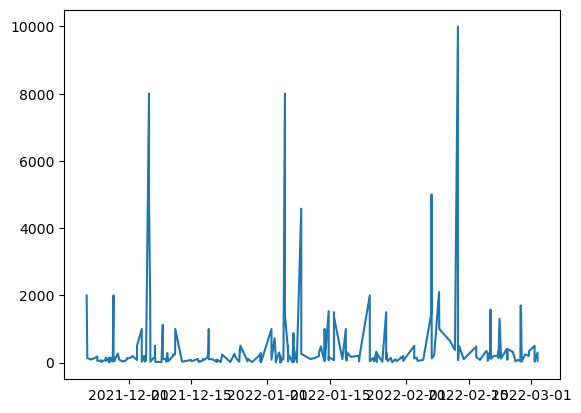

In [187]:
# plot graph
import matplotlib.pyplot as plt
plt.plot(df['Date'],df['INR'])

<Axes: xlabel='day_name'>

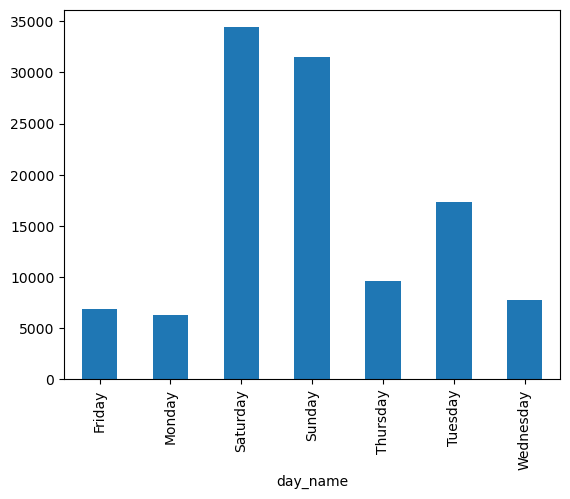

In [191]:
# day name wise bar chart
df['day_name'] = df['Date'].dt.day_name()
df.groupby('day_name')['INR'].sum().plot(kind='bar')

In [192]:
df['month_name'] = df['Date'].dt.month_name()


<Axes: xlabel='month_name'>

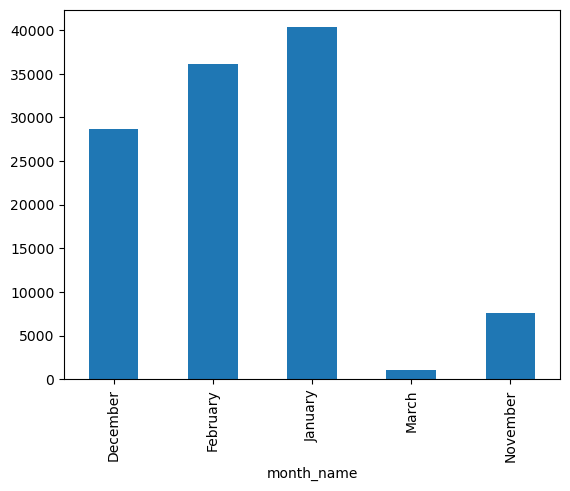

In [194]:
df.groupby('month_name')['INR'].sum().plot(kind='bar')


<Axes: >

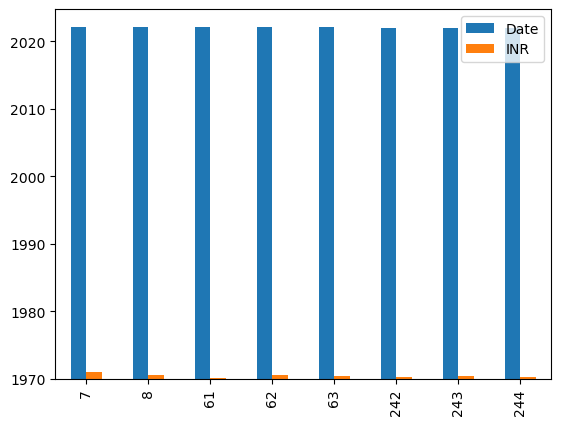

In [ ]:
# month end mai kharcha
df[df['Date'].dt.is_month_end][['Date','INR']]